# CEE6501 — Coding Assignment, Week 10

**Assigned:** 03/20/2026 (Week 10)  
**Due:** 03/30/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320768>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Name this notebook as: `LastName_A#_code.ipynb`
- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - Permissions on the file are properly set for others to access
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---
---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [221]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


## Imports & Version Check

Run this cell once before starting the assignment to import packages.

In [222]:
import numpy as np
import scipy
import matplotlib
import pandas as pd
import plotly

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pd.__version__)
print("plotly:", plotly.__version__)

import matplotlib.pyplot as plt
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


---
---

## Assignment Instructions

In this assignment, you will build on your frame-analysis code from `A8_code.ipynb`:

1. Extend your solver to handle **prescribed support displacements** (support settlements).
2. Extend your solver to handle **temperature effects**
3. Extend your solver to handle **fabrication error effects**

Confirm your code is correct by validating using your hand calculated solutions for the all the questions in `A10_written.md`
- Question 1 — Support Displacements
- Question 2 — Temperature Effects
- Question 3 — Fabrication / Fit-up Errors

### Response (For each question)

Address the following points:

- **Verification:**  
  Confirm whether your computed results match your hand calculations.  
  Identify which quantities you compared (for example: key displacements, reactions, or member end forces).

- **Key results:**  
  Summarize the most important outcomes from your analysis, including representative:
  - **nodal displacements**
  - **support reactions**
  - **member end forces**

- **Reasonableness check:**  
  Briefly explain why the results make sense from a **structural mechanics perspective** (for example: expected deformation direction, magnitude of reactions, or moment distribution).

### Notes
- Use consistent DOF ordering (as in lecture). For a 2D frame node, a common ordering is:
  - $[u_x,\; u_y,\; \theta_z]$ per node
- Clearly document your conventions at the top of your code.
- Use **plots** to help validate and interpret results.

---

### helper_funcs_dsm

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qf_list,
    map_list,
):
    """
    Assemble global stiffness matrix and global fixed-end force vector.

    Automatically handles 6-DOF (frame) and 4-DOF (truss/beam) elements.
    Parameters
    ----------
    ndof : int
        Total number of global degrees of freedom.

    k_list : list of ndarray
        List of local element stiffness matrices.
        Each matrix may be 6x6 (frame) or 4x4 (truss/beam).

    T_list : list of ndarray
        List of element transformation matrices corresponding
        to each k_local. Must be compatible in size.

    Qf_list : list of ndarray
        List of local fixed-end force vectors for each element.
        Size must match the element DOF count.

    map_list : list of array-like
        List of element DOF maps (1-based indexing).
        Each map defines where the element DOFs connect
        into the global DOF numbering.

    Returns
    -------
    K_global : ndarray (ndof x ndof)
        Assembled global stiffness matrix.

    F_fef_global : ndarray (ndof,)
        Assembled global fixed-end force vector.

    Notes
    -----
    - DOF maps are assumed to use 1-based indexing.
    - Internally converted to 0-based indexing for Python.
    - Assembly is dense; for large systems a sparse format
      should be used instead.
    """

    K_global = np.zeros((ndof, ndof), dtype=float)
    F_fef_global = np.zeros(ndof, dtype=float)

    nelem = len(k_list)

    for i in range(nelem):

        k_local = k_list[i]
        T = T_list[i]
        Qf_local = Qf_list[i]
        dof_map = map_list[i]  # 1-based indexing

        # Determine element DOF count automatically
        edof = k_local.shape[0]

        # Transform to global
        K = T.T @ k_local @ T
        F_fef = T.T @ Qf_local

        # Scatter-add
        for a in range(edof):
            A = dof_map[a] - 1  # convert to 0-based

            F_fef_global[A] += F_fef[a]

            for b in range(edof):
                B = dof_map[b] - 1
                K_global[A, B] += K[a, b]

    return K_global, F_fef_global


def partition_system(K, f, u, f_fef, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(int(d) - 1 for d in dof_restrained_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    # Partition displaced vector
    u_r = u[restrained_dofs]

    # Partition fixed-end forces
    f_fef_f = f_fef[free_dofs]
    f_fef_r = f_fef[restrained_dofs]

    return (
        K_ff,
        K_fr,
        K_rf,
        K_rr,
        f_f,
        f_r,
        u_r,
        f_fef_f,
        f_fef_r,
        free_dofs,
        restrained_dofs,
    )


def assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    if u_r is None:
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global


def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global



### helper_funcs_output

In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    dof_fictitious_1based=None,  # optional kwarg
    disp_in_mm=False,
    member_type="frame",
):
    ndof = len(u_global)
    rows = []

    # Ensure arrays
    dof_restrained_1based = np.atleast_1d(dof_restrained_1based)

    if dof_fictitious_1based is None:
        dof_fictitious_1based = np.array([], dtype=int)
    else:
        dof_fictitious_1based = np.atleast_1d(dof_fictitious_1based)

    restrained_set = {int(d) for d in dof_restrained_1based}
    fictitious_set = {int(d) for d in dof_fictitious_1based}

    member_type = member_type.lower()

    if member_type == "frame":
        dof_labels = ["u_x", "u_y", "theta"]
        translational_idx = {0, 1}
    elif member_type == "truss":
        dof_labels = ["u_x", "u_y"]
        translational_idx = {0, 1}
    elif member_type == "beam":
        dof_labels = ["u_y", "theta"]
        translational_idx = {0}
    else:
        raise ValueError("member_type must be 'frame', 'truss', or 'beam'")

    dof_per_node = len(dof_labels)

    for i in range(ndof):
        dof_1based = i + 1
        mod = i % dof_per_node
        dof_type = dof_labels[mod]

        if mod in translational_idx:
            disp = u_global[i] * (1000 if disp_in_mm else 1)
        else:
            disp = u_global[i]

        if dof_1based in fictitious_set:
            status = "Fictitious"
        elif dof_1based in restrained_set:
            status = "Fixed"
        else:
            status = "Free"

        rows.append([dof_1based, dof_type, status, disp, f_global_complete[i]])

    disp_unit = "mm" if disp_in_mm else "m"

    df = pd.DataFrame(
        rows,
        columns=[
            "DOF",
            "Type",
            "Status",
            f"Disp ({disp_unit} / rad)",
            "Load (kN / kN·m)",
        ],
    )

    print(df.to_string(index=False, float_format="%.3f"))


def print_element(
    e, u_global, m_1based, T, k, Qf, disp_in_mm=False, dec=3, rad_dec=4
):

    idx = m_1based - 1
    u = u_global[idx]
    v = T @ u
    q = k @ v + Qf

    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"

    # Scale translations only (0,1,3,4) — rotations (2,5) untouched
    u_out = u.copy()
    v_out = v.copy()
    for j in [0, 1, 3, 4]:
        u_out[j] *= scale
        v_out[j] *= scale

    def fmt_disp(vec):
        parts = []
        for j, val in enumerate(vec):
            if j % 3 == 2:  # rotation (rad)
                parts.append(f"{val:.{rad_dec}f}")
            else:  # translation
                parts.append(f"{val:.{dec}f}")
        return "[" + ", ".join(parts) + "]"
    

    def fmt_force(vec):
        # forces (kN) and moments (kN·m) both use dec
        return "[" + ", ".join(f"{val:.{dec}f}" for val in vec) + "]"

    print(f"\nE{e}")
    print(f"u [{unit},rad]: {fmt_disp(u_out)}")
    print(f"v [{unit},rad]: {fmt_disp(v_out)}")
    print(f"q [kN,kN·m]: {fmt_force(q)}")


def print_element_truss(
    e,
    u_global,
    m_1based,
    T,
    k_local,
    Qf_local=None,
    disp_in_mm=False,
    dec=3,
):
    """
    Print element-level results for a 2D truss element.

    Parameters
    ----------
    e : int
        Element number for printing.
    u_global : (ndof,) array
        Global displacement vector.
    m_1based : (4,) array-like
        Global DOF map for this element (1-based indexing).
    T : (4,4) array
        Transformation matrix (global -> local).
    k_local : (4,4) array
        Local truss stiffness matrix (typically axial-only with 1/-1 pattern).
    Qf_local : (4,) array or None
        Local fixed-end / initial-force vector. If None, assumed zero.
        (Usually zero for trusses unless you model prestrain/temperature/etc.)
    disp_in_mm : bool
        If True, print translations in mm.
    dec : int
        Decimal places for printing.

    Prints
    ------
    - Element global displacement subvector u_e (translations)
    - Element local displacement vector u'_e
    - Element local end force vector q'_e
    - Axial force N (tension positive), computed as N = Fx_j' = -Fx_i'
    """

    idx = np.asarray(m_1based, dtype=int) - 1
    u_e = u_global[idx]  # [uix, uiy, ujx, ujy]

    if Qf_local is None:
        Qf_local = np.zeros(4, dtype=float)

    u_loc = T @ u_e
    q_loc = k_local @ u_loc + Qf_local  # [Fx_i', Fy_i', Fx_j', Fy_j']

    # scale translations for printing
    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"
    u_out = u_e * scale
    uloc_out = u_loc * scale

    def fmt(vec):
        return "[" + ", ".join(f"{v:.{dec}f}" for v in vec) + "]"

    # axial force (tension +): for a pure truss, Fy' should be ~0
    # N_i = q_loc[0]  # Fx at i in local axis
    N_j = q_loc[2]  # Fx at j in local axis
    N = N_j  # report axial as end force at j (should equal -N_i)

    print(f"\nE{e} (Truss)")
    print(f"u_global [{unit}]: {fmt(u_out)}")
    print(f"u_local  [{unit}]: {fmt(uloc_out)}")
    print(f"q_local  [kN]: {fmt(q_loc)}")
    print(f"N (tension +) = {N:.{dec}f} kN\n")


def print_matrix_scaled(K, scale=1000, decimals=1, col_width=3):
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:02d} | {row_str}")


def plot_truss_deformation(nodes, elements, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    plt.figure()

    for e_id, (i, j, *_) in elements.items():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        ui = u_global[2 * (i - 1) : 2 * (i - 1) + 2]
        uj = u_global[2 * (j - 1) : 2 * (j - 1) + 2]

        # original
        plt.plot([xi, xj], [yi, yj], "k-", lw=2)

        # deformed
        plt.plot(
            [xi + scale * ui[0], xj + scale * uj[0]],
            [yi + scale * ui[1], yj + scale * uj[1]],
            "r-",
            lw=2,
        )

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()


### my own funcs based on truss dsm

In [225]:
def restrained_dofs_1based(nodes_restrained, node_dofs_1based):
    dof_restrained = []

    for node, restraints in nodes_restrained.items():
        ux_dof, uy_dof, rot_dof = node_dofs_1based(node)
        if "ux" in restraints:
            dof_restrained.append(ux_dof)
        if "uy" in restraints:
            dof_restrained.append(uy_dof)
        if "rot" in restraints:
            dof_restrained.append(rot_dof)

    return sorted(dof_restrained)

In [226]:
def FEF_cal(load_type, Fx, Fy, M, L):

    if load_type == "p":
        f_local = np.array([
            -Fx / 2.0,
            3.0 * M / (2.0 * L) - Fy / 2.0,
            M / 4.0 - Fy * L / 8.0,
            -Fx / 2.0,
            -3.0 * M / (2.0 * L) - Fy / 2.0,
            M / 4.0 + Fy * L / 8.0
        ], dtype=float)

    elif load_type == "d":
        f_local = np.array([
            -Fx * L / 2.0,
            M - Fy * L / 2.0,
            -Fy * L**2 / 12.0,
            -Fx * L / 2.0,
            -M - Fy * L / 2.0,
            Fy * L**2 / 12.0
        ], dtype=float)

    else:
        raise ValueError('load_type must be "p" or "d".')

    Fx_i, Fy_i, M_i, Fx_j, Fy_j, M_j = f_local

    FEF_loaded = np.array([Fx_i, Fy_i, M_i, Fx_j, Fy_j, M_j])

    return FEF_loaded

In [227]:
def loaded_dofs_1based(nodes_loaded, FEF_loaded, node_dofs_1based):
    dof_loaded = {}

    if nodes_loaded:
        for node, (Fx, Fy, M) in nodes_loaded.items():
            ux_dof, uy_dof, rot_dof = node_dofs_1based(node)
            if Fx != 0.0:
                dof_loaded[ux_dof] = dof_loaded.get(ux_dof, 0.0) + Fx
            if Fy != 0.0:
                dof_loaded[uy_dof] = dof_loaded.get(uy_dof, 0.0) + Fy
            if M != 0.0:
                dof_loaded[rot_dof] = dof_loaded.get(rot_dof, 0.0) + M

    if FEF_loaded:
        for node, (Fx, Fy, M) in FEF_loaded.items():
            ux_dof, uy_dof, rot_dof = node_dofs_1based(node)
            if Fx != 0.0:
                dof_loaded[ux_dof] = dof_loaded.get(ux_dof, 0.0) + Fx
            if Fy != 0.0:
                dof_loaded[uy_dof] = dof_loaded.get(uy_dof, 0.0) + Fy
            if M != 0.0:
                dof_loaded[rot_dof] = dof_loaded.get(rot_dof, 0.0) + M

    return dof_loaded

In [228]:
def node_dofs_1based(node_id):
    """Return engineering DOF numbers (1-based): [ux_dof, uy_dof, rot_dof]."""
    return [3 * node_id - 2, 3 * node_id - 1, 3 * node_id]

In [229]:
def element_csL(xy_i, xy_j):
    xy_i = np.asarray(xy_i, dtype=float)
    xy_j = np.asarray(xy_j, dtype=float)

    dx = xy_j[0] - xy_i[0]
    dy = xy_j[1] - xy_i[1]
    L = float(np.hypot(dx, dy))

    c = dx / L
    s = dy / L
    return float(c), float(s), float(L)


In [230]:
def build_elements_csl(elements, nodes):
    """Return dict mapping element_id -> (c, s, L)."""
    elements_csl = {}

    for e_id, (i, j, E_e, A_e, I_e) in elements.items():
        c, s, L = element_csL(nodes[i], nodes[j])
        elements_csl[e_id] = (c, s, L)

    return elements_csl

In [231]:
def initialize_global_stiffness(nodes):
    """Return zero-initialized global stiffness matrix."""
    ndof_total = 3 * len(nodes)
    return np.zeros((ndof_total, ndof_total), dtype=float)

In [232]:
def frame_element_kl(E, A, I, L):

    kl = (E * I) / L ** 3 * np.array([
        [A * L**2 / I, 0, 0, -A * L**2 / I, 0, 0],
        [0, 12, 6 * L, 0, -12, 6 * L],
        [0, 6 * L, 4 * L**2, 0, -6 * L, 2 * L**2],
        [-A * L**2 / I, 0, 0, A * L**2 / I, 0, 0],
        [0, -12, -6 * L, 0, 12, -6 * L],
        [0, 6 * L, 2 * L**2, 0, -6 * L, 4 * L**2]
    ], dtype=float)

    return kl

In [233]:
def frame_transformation_matrix(c, s):
    return np.array([
        [c, s, 0, 0, 0, 0],
        [-s, c, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, c, s, 0],
        [0, 0, 0, -s, c, 0],
        [0, 0, 0, 0, 0, 1]
    ], dtype=float)

In [234]:
def element_dof_map_1based(i_node, j_node):
    """Return the 6 global DOF indices (1-based) for element (i, j).

    Order matches the 6x6 element stiffness matrix:
    [u_ix, u_iy, theta_i, u_jx, u_jy, theta_j]
    """
    # Engineering DOF numbers (1-based)
    dofs_i_1 = [3 * i_node - 2, 3 * i_node - 1, 3 * i_node]
    dofs_j_1 = [3 * j_node - 2, 3 * j_node - 1, 3 * j_node]
    dofs_1based = dofs_i_1 + dofs_j_1
    return dofs_1based

In [235]:
def frame_deflection(x, L, uy_i, th_i, uy_j, th_j):
    """
    Local transverse displacement uy(x) (cubic).
    """
    N1, N2, N3, N4 = frame_shape_functions(x, L)
    return N1 * uy_i + N2 * th_i + N3 * uy_j + N4 * th_j

def frame_shape_functions(x, L):
    """
    Cubic shape functions for transverse displacement (same as beam).
    x can be scalar or numpy array.
    """
    x = np.asarray(x, dtype=float)
    xi = x / L
    N1 = 1.0 - 3.0 * xi**2 + 2.0 * xi**3
    N2 = L * (xi - 2.0 * xi**2 + xi**3)
    N3 = 3.0 * xi**2 - 2.0 * xi**3
    N4 = L * (-xi**2 + xi**3)

    return N1, N2, N3, N4

In [236]:
def plot_deformed_frame_2d(nodes, elements, U, scale=1.0, npts=500):
    """
    Problem 2 — Frame

    Plot undeformed and deformed shape for a 2D frame

    Inputs
    ------
    nodes : dict
        {node_id: (x, y)}
    elements : dict
        {elem_id: (i, j)}
    U : array-like
        Global displacement vector with [ux, uy, th] per node
    scale : float
        Deformation scale factor
    npts : int
        Number of sample points per element

    Tasks
    -----
    1) Loop through elements
    2) Compute L, c, s
    3) Extract (ux_i, uy_i, th_i, ux_j, uy_j, th_j) from U
    4) Compute ux(x) (linear) and uy(x) (cubic)
    5) Transform local displacement to global
    6) Plot undeformed and deformed structures
    """

    # TODO: implement
    plt.figure(figsize=(3, 2.5), dpi=300)

    x_nodes = []
    y_nodes = []
    for x, y in nodes.values():
        x_nodes.append(x)
        y_nodes.append(y)
    plt.scatter(x_nodes, y_nodes)

    for elem in elements.values():
        i, j = elem[0], elem[1]

        xi, yi = nodes[i]
        xj, yj = nodes[j]

        dx = xj - xi
        dy = yj - yi

        L = (dx*dx + dy*dy) ** 0.5
        c = dx / L
        s = dy / L

        ux_i = U[3 * i - 3]
        uy_i = U[3 * i - 2]
        theta_i = U[3 * i - 1]
        ux_j = U[3 * j - 3]
        uy_j = U[3 * j - 2]
        theta_j = U[3 * j - 1]

        uxlocal_i =  c * ux_i + s * uy_i
        uylocal_i = -s * ux_i + c * uy_i

        uxlocal_j =  c * ux_j + s * uy_j
        uylocal_j = -s * ux_j + c * uy_j

        dx = np.linspace(0.0, L, npts)

        x0 = xi + c * dx
        y0 = yi + s * dx

        # Axial interpolation
        ux_local = (1.0 - dx / L) * uxlocal_i + (dx / L) * uxlocal_j

        # Transverse interpolation
        uy_local = frame_deflection(dx, L, uylocal_i, theta_i, uylocal_j, theta_j)

        ux_global = c * ux_local - s * uy_local
        uy_global = s * ux_local + c * uy_local

        x1 = x0 + scale * ux_global
        y1 = y0 + scale * uy_global

        plt.plot(x0, y0)
        plt.plot(x1, y1)

    plt.axis("equal")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title("Frame Deformed Shape")
    plt.show()

### model setup

In [237]:
# Node coordinates (global)
nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0)
}                  # m

# Material and section properties
E = 200e6          # kPa
A = 4.74e-3         # m^2
I = 22.2e-6         # m^4

# Element connectivity and properties
# Format: element_id : (start_node, end_node, E, A)
elements = {
    1: (1, 2, E, A, I),
    2: (2, 3, E, A, I)
}

elements_csl = build_elements_csl(elements, nodes)

print (elements)
print(elements_csl)

{1: (1, 2, 200000000.0, 0.00474, 2.22e-05), 2: (2, 3, 200000000.0, 0.00474, 2.22e-05)}
{1: (0.0, 1.0, 10.0), 2: (1.0, 0.0, 8.0)}


In [238]:
# Node-level description of restraints
# Values indicate which DOFs are fixed at each node
nodes_restrained = {
    1: ["ux", "uy", "rot"],   # fix
    3: ["ux", "uy"]          # pin
}

# Node-level applied loads (Fx, Fy, M)
nodes_loaded = None

# Element-level applied loads (type, Fx, Fy, M)
elements_loaded = {
    1: ("d", 0.0, -24.0, 0.0),  # element 1: local y-direction uniform load kNm
    2: ("p", 0.0, -75.0, 0.0)   # element 2: midpoint concentrated load kN
}


In [239]:
k_list = []
T_list = []
Qf_list = []
map_list = []
for e_id in elements:
    c, s, L = elements_csl[e_id]
    load_type, Fx, Fy, M = elements_loaded[e_id]

    kl = frame_element_kl(E, A, I, L)
    T = frame_transformation_matrix(c, s)
    Qf = FEF_cal(load_type, Fx, Fy, M, L)
    m = element_dof_map_1based(elements[e_id][0], elements[e_id][1])

    k_list.append(kl)
    T_list.append(T)
    Qf_list.append(Qf)
    map_list.append(m)

print(k_list)
print(T_list)
print(Qf_list)
print(map_list)

ndof = int(np.max(np.concatenate(map_list)))

[array([[ 94800.  ,      0.  ,      0.  , -94800.  ,      0.  ,      0.  ],
       [     0.  ,     53.28,    266.4 ,      0.  ,    -53.28,    266.4 ],
       [     0.  ,    266.4 ,   1776.  ,      0.  ,   -266.4 ,    888.  ],
       [-94800.  ,      0.  ,      0.  ,  94800.  ,      0.  ,      0.  ],
       [     0.  ,    -53.28,   -266.4 ,      0.  ,     53.28,   -266.4 ],
       [     0.  ,    266.4 ,    888.  ,      0.  ,   -266.4 ,   1776.  ]]), array([[ 118500.   ,       0.   ,       0.   , -118500.   ,       0.   ,
              0.   ],
       [      0.   ,     104.062,     416.25 ,       0.   ,    -104.062,
            416.25 ],
       [      0.   ,     416.25 ,    2220.   ,       0.   ,    -416.25 ,
           1110.   ],
       [-118500.   ,       0.   ,       0.   ,  118500.   ,       0.   ,
              0.   ],
       [      0.   ,    -104.062,    -416.25 ,       0.   ,     104.062,
           -416.25 ],
       [      0.   ,     416.25 ,    1110.   ,       0.   ,    -416.25 ,

---

## Response (Question 1)


In [240]:
dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_fictitious_1based = np.array([], dtype=int)

dof_restrained_1based = np.sort(
    np.concatenate((dof_restrained_1based, dof_fictitious_1based))
)

F_global = np.zeros(ndof, dtype=float)
u_global = np.zeros(ndof, dtype=float)
u_global[2] = 0.01    # rad
u_global[6] = 0.005   # m
u_global[7] = -0.01  # m


In [241]:
K_global, F_fef_global = assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qf_list,
    map_list
    )
print(K_global,"\n")
print(F_fef_global)

[[     53.28        0.       -266.4       -53.28        0.       -266.4
        0.          0.          0.   ]
 [      0.      94800.          0.          0.     -94800.          0.
        0.          0.          0.   ]
 [   -266.4         0.       1776.        266.4         0.        888.
        0.          0.          0.   ]
 [    -53.28        0.        266.4    118553.28        0.        266.4
  -118500.          0.          0.   ]
 [      0.     -94800.          0.          0.      94904.063     416.25
        0.       -104.062     416.25 ]
 [   -266.4         0.        888.        266.4       416.25     3996.
        0.       -416.25     1110.   ]
 [      0.          0.          0.    -118500.          0.          0.
   118500.          0.          0.   ]
 [      0.          0.          0.          0.       -104.062    -416.25
        0.        104.062    -416.25 ]
 [      0.          0.          0.          0.        416.25     1110.
        0.       -416.25     2220.   ]] 

[

In [242]:
(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    u_r,
    f_fef_f,
    f_fef_r,
    free_dofs,
    restrained_dofs,
) = partition_system(
    K_global,
    F_global,
    u_global,
    F_fef_global,
    dof_restrained_1based
)


In [243]:
rhs = f_f - f_fef_f - K_fr @ u_r
u_f = np.linalg.solve(K_ff, rhs)

F_r = K_rf @ u_f + K_rr @ u_r + f_fef_r

u_global = assemble_global_displacements(
    u_f,
    u_r,
    free_dofs,
    restrained_dofs
    )

f_global_complete = assemble_global_forces(
    f_f,
    F_r,
    free_dofs,
    restrained_dofs
    )

In [244]:
print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    dof_fictitious_1based,
    disp_in_mm=True
)

 DOF  Type Status  Disp (mm / rad)  Load (kN / kN·m)
   1   u_x  Fixed            0.000          -128.793
   2   u_y  Fixed            0.000            56.348
   3 theta  Fixed            0.010           238.718
   4   u_x   Free            5.938             0.000
   5   u_y   Free           -0.594             0.000
   6 theta   Free            0.022             0.000
   7   u_x  Fixed            5.000          -111.207
   8   u_y  Fixed          -10.000            18.652
   9 theta   Free            0.021             0.000


In [245]:
for i in range(len(k_list)):
    map_list = [np.array(m) for m in map_list]
    m = map_list[i]
    T = T_list[i]
    k = k_list[i]
    Qf = Qf_list[i]

    print_element(i + 1, u_global, m, T, k, Qf, disp_in_mm=True, dec=1)


E1
u [mm,rad]: [0.0, 0.0, 0.0100, 5.9, -0.6, 0.0218]
v [mm,rad]: [0.0, 0.0, 0.0100, -0.6, -5.9, 0.0218]
q [kN,kN·m]: [56.3, 128.8, 238.7, -56.3, 111.2, -150.8]

E2
u [mm,rad]: [5.9, -0.6, 0.0218, 5.0, -10.0, 0.0211]
v [mm,rad]: [5.9, -0.6, 0.0218, 5.0, -10.0, 0.0211]
q [kN,kN·m]: [111.2, 56.3, 150.8, -111.2, 18.7, 0.0]


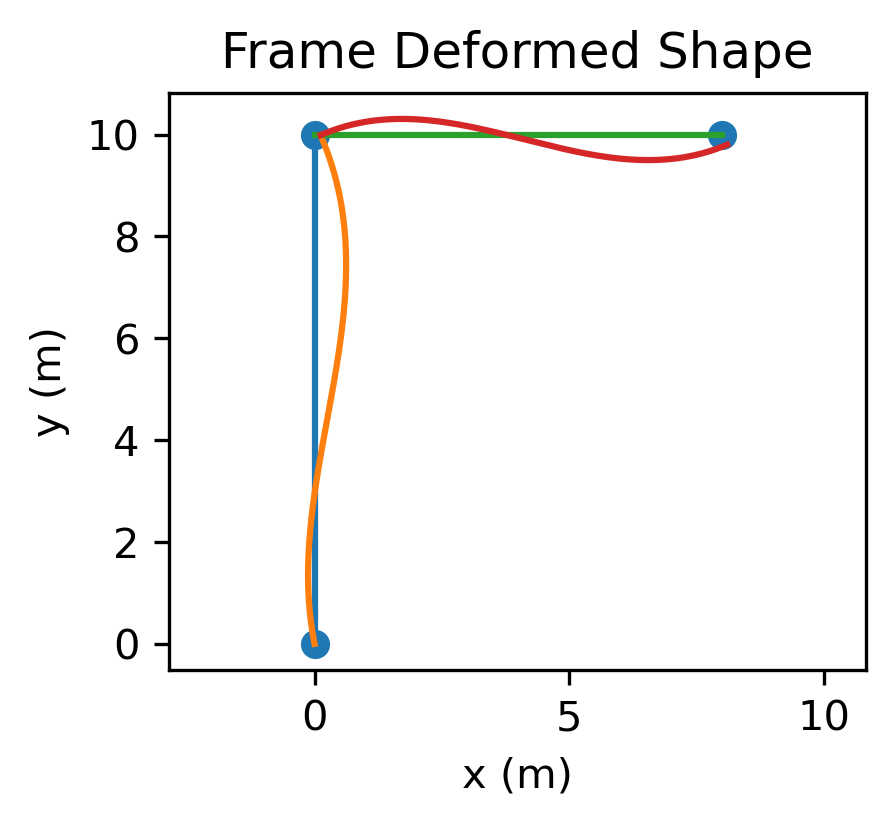

In [246]:
u = u_global.tolist()

plot_deformed_frame_2d(nodes, elements, u, scale=20, npts=500)

### Response for Question 1

For Question 1, the code and my hand calculation are basically telling the same story. From the written work, I got about $u_{2x}=5.938\ \text{mm}$, $u_{2y}=-0.595\ \text{mm}$, and $\theta_2=0.02182\ \text{rad}$. The code gave $u_{2x}=5.938\ \text{mm}$, $u_{2y}=-0.594\ \text{mm}$, and $\theta_2\approx 0.022\ \text{rad}$. For reactions, the hand result gave about $F_{1x}=-128.794\ \text{kN}$ and $M_1=238.719\ \text{kN}\cdot\text{m}$, while the code gave $F_{1x}=-128.793\ \text{kN}$ and $M_1=238.718\ \text{kN}\cdot\text{m}$. So overall the match is very good. The only small differences are in a few reaction values, and those are just tiny rounding-level differences.

dahidnbn

## Response (Question 2)

ADD YOUR TEXT AND OUTPUT PLOTS AND TABLES HERE

In [247]:
def heat_cal(T_t, T_b, E, A, I, d, alpha):
    
    N_h = E * alpha * A * (T_t + T_b) / 2
    M_h = E * alpha * I * (T_b - T_t) / d
    Qh = [
        N_h,
        0.0,
        M_h,
        -N_h,
        0.0,
        -M_h
    ]

    return Qh

In [248]:
Tt_list = [10, 15]
Tb_list = [10, 5]
alpha = 1.2e-5

d = 0.3 # To be determined


Qh_list = []
for e_id in elements:
    c, s, L = elements_csl[e_id]
    load_type, Fx, Fy, M = elements_loaded[e_id]
    T_t = Tt_list[e_id-1]
    T_b = Tb_list[e_id-1]

    Qh = heat_cal(T_t, T_b, E, A, I, d, alpha)

    Qh_list.append(Qh)

print(Qh_list)

Qt_list = [x + y for x, y in zip(Qf_list, Qh_list)] #Q_total
print(Qt_list)

ndof = int(np.max(np.concatenate(map_list)))

[[113.76000000000002, 0.0, 0.0, -113.76000000000002, 0.0, -0.0], [113.76000000000002, 0.0, -1.7760000000000002, -113.76000000000002, 0.0, 1.7760000000000002]]
[array([ 113.76,  120.  ,  200.  , -113.76,  120.  , -200.  ]), array([ 113.76 ,   37.5  ,   73.224, -113.76 ,   37.5  ,  -73.224])]


In [249]:
dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_fictitious_1based = np.array([], dtype=int)

dof_restrained_1based = np.sort(
    np.concatenate((dof_restrained_1based, dof_fictitious_1based))
)

F_global = np.zeros(ndof, dtype=float)
u_global = np.zeros(ndof, dtype=float)

In [250]:
K_global, F_fef_global = assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qt_list,
    map_list
    )
print(K_global,"\n")
print(F_fef_global)

[[     53.28        0.       -266.4       -53.28        0.       -266.4
        0.          0.          0.   ]
 [      0.      94800.          0.          0.     -94800.          0.
        0.          0.          0.   ]
 [   -266.4         0.       1776.        266.4         0.        888.
        0.          0.          0.   ]
 [    -53.28        0.        266.4    118553.28        0.        266.4
  -118500.          0.          0.   ]
 [      0.     -94800.          0.          0.      94904.063     416.25
        0.       -104.062     416.25 ]
 [   -266.4         0.        888.        266.4       416.25     3996.
        0.       -416.25     1110.   ]
 [      0.          0.          0.    -118500.          0.          0.
   118500.          0.          0.   ]
 [      0.          0.          0.          0.       -104.062    -416.25
        0.        104.062    -416.25 ]
 [      0.          0.          0.          0.        416.25     1110.
        0.       -416.25     2220.   ]] 

[

In [251]:
(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    u_r,
    f_fef_f,
    f_fef_r,
    free_dofs,
    restrained_dofs,
) = partition_system(
    K_global,
    F_global,
    u_global,
    F_fef_global,
    dof_restrained_1based
)


In [252]:
rhs = f_f - f_fef_f - K_fr @ u_r
u_f = np.linalg.solve(K_ff, rhs)

F_r = K_rf @ u_f + K_rr @ u_r + f_fef_r

u_global = assemble_global_displacements(
    u_f,
    u_r,
    free_dofs,
    restrained_dofs
    )

f_global_complete = assemble_global_forces(
    f_f,
    F_r,
    free_dofs,
    restrained_dofs
    )

In [253]:
print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    dof_fictitious_1based,
    disp_in_mm=True
)

 DOF  Type Status  Disp (mm / rad)  Load (kN / kN·m)
   1   u_x  Fixed            0.000          -126.971
   2   u_y  Fixed            0.000            56.691
   3 theta  Fixed            0.000           223.235
   4   u_x   Free           -0.006             0.000
   5   u_y   Free            0.602             0.000
   6 theta   Free            0.026             0.000
   7   u_x  Fixed            0.000          -113.029
   8   u_y  Fixed            0.000            18.309
   9 theta   Free            0.020             0.000


In [254]:
for i in range(len(k_list)):
    map_list = [np.array(m) for m in map_list]
    m = map_list[i]
    T = T_list[i]
    k = k_list[i]
    Qt = Qt_list[i]

    print_element(i + 1, u_global, m, T, k, Qt, disp_in_mm=True, dec=1)


E1
u [mm,rad]: [0.0, 0.0, 0.0000, -0.0, 0.6, 0.0262]
v [mm,rad]: [0.0, 0.0, 0.0000, 0.6, 0.0, 0.0262]
q [kN,kN·m]: [56.7, 127.0, 223.2, -56.7, 113.0, -153.5]

E2
u [mm,rad]: [-0.0, 0.6, 0.0262, 0.0, 0.0, 0.0198]
v [mm,rad]: [-0.0, 0.6, 0.0262, 0.0, 0.0, 0.0198]
q [kN,kN·m]: [113.0, 56.7, 153.5, -113.0, 18.3, 0.0]


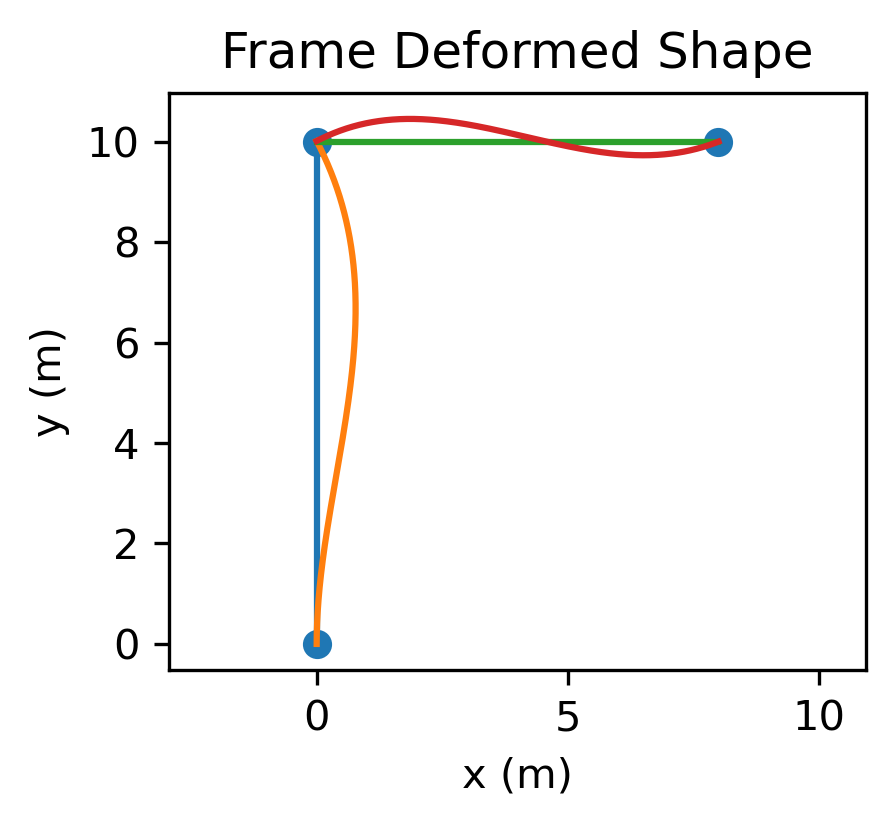

In [255]:
u = u_global.tolist()

plot_deformed_frame_2d(nodes, elements, u, scale=20, npts=500)

### Response for Question 2

Question 2 matched even better. In the written solution, the key values were about $u_{2x}=-0.006\ \text{mm}$, $u_{2y}=0.602\ \text{mm}$, $\theta_2=0.02617\ \text{rad}$, and $M_1=223.235\ \text{kN}\cdot\text{m}$. The code gave essentially the same numbers: $u_{2x}=-0.006\ \text{mm}$, $u_{2y}=0.602\ \text{mm}$, $\theta_2\approx 0.026\ \text{rad}$, and $M_1=223.235\ \text{kN}\cdot\text{m}$. I also checked a local member force, and the code gave about $113.029\ \text{kN}$, which is the same as the hand result to the shown digits. This one is probably the cleanest comparison, so I am confident the temperature-load part in the code is working correctly.

## Response (Question 3)

ADD YOUR TEXT AND OUTPUT PLOTS AND TABLES HERE

In [256]:
def fabrication_error_cal(e_a, E, A, L):
    
    N_e = E * A * e_a / L
    Qe = [
        N_e,
        0.0,
        0.0,
        -N_e,
        0.0,
        0.0
    ]

    return Qe

In [257]:
ea_list= [-0.003, -0.003]

Qe_list = []
for e_id in elements:
    c, s, L = elements_csl[e_id]
    load_type, Fx, Fy, M = elements_loaded[e_id]
    e_a = ea_list[e_id-1]

    Qe = fabrication_error_cal(e_a, E, A, L)

    Qe_list.append(Qe)

print(Qe_list)

Qt_list = [x + y for x, y in zip(Qf_list, Qe_list)] #Q_total
print(Qt_list)

[[-284.4, 0.0, 0.0, 284.4, 0.0, 0.0], [-355.5, 0.0, 0.0, 355.5, 0.0, 0.0]]
[array([-284.4,  120. ,  200. ,  284.4,  120. , -200. ]), array([-355.5,   37.5,   75. ,  355.5,   37.5,  -75. ])]


In [258]:
dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_fictitious_1based = np.array([], dtype=int)

dof_restrained_1based = np.sort(
    np.concatenate((dof_restrained_1based, dof_fictitious_1based))
)

F_global = np.zeros(ndof, dtype=float)
u_global = np.zeros(ndof, dtype=float)

In [259]:
K_global, F_fef_global = assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qt_list,
    map_list
    )
print(K_global,"\n")
print(F_fef_global)

[[     53.28        0.       -266.4       -53.28        0.       -266.4
        0.          0.          0.   ]
 [      0.      94800.          0.          0.     -94800.          0.
        0.          0.          0.   ]
 [   -266.4         0.       1776.        266.4         0.        888.
        0.          0.          0.   ]
 [    -53.28        0.        266.4    118553.28        0.        266.4
  -118500.          0.          0.   ]
 [      0.     -94800.          0.          0.      94904.063     416.25
        0.       -104.062     416.25 ]
 [   -266.4         0.        888.        266.4       416.25     3996.
        0.       -416.25     1110.   ]
 [      0.          0.          0.    -118500.          0.          0.
   118500.          0.          0.   ]
 [      0.          0.          0.          0.       -104.062    -416.25
        0.        104.062    -416.25 ]
 [      0.          0.          0.          0.        416.25     1110.
        0.       -416.25     2220.   ]] 

[

In [260]:
(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    u_r,
    f_fef_f,
    f_fef_r,
    free_dofs,
    restrained_dofs,
) = partition_system(
    K_global,
    F_global,
    u_global,
    F_fef_global,
    dof_restrained_1based
)


In [261]:
rhs = f_f - f_fef_f - K_fr @ u_r
u_f = np.linalg.solve(K_ff, rhs)

F_r = K_rf @ u_f + K_rr @ u_r + f_fef_r

u_global = assemble_global_displacements(
    u_f,
    u_r,
    free_dofs,
    restrained_dofs
    )

f_global_complete = assemble_global_forces(
    f_f,
    F_r,
    free_dofs,
    restrained_dofs
    )

In [262]:
print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    dof_fictitious_1based,
    disp_in_mm=True
)

 DOF  Type Status  Disp (mm / rad)  Load (kN / kN·m)
   1   u_x  Fixed            0.000          -126.961
   2   u_y  Fixed            0.000            56.743
   3 theta  Fixed            0.000           223.555
   4   u_x   Free            3.954             0.000
   5   u_y   Free           -3.599             0.000
   6 theta   Free            0.025             0.000
   7   u_x  Fixed            0.000          -113.039
   8   u_y  Fixed            0.000            18.257
   9 theta   Free            0.022             0.000


In [263]:
for i in range(len(k_list)):
    map_list = [np.array(m) for m in map_list]
    m = map_list[i]
    T = T_list[i]
    k = k_list[i]
    Qt = Qt_list[i]

    print_element(i + 1, u_global, m, T, k, Qt, disp_in_mm=True, dec=1)


E1
u [mm,rad]: [0.0, 0.0, 0.0000, 4.0, -3.6, 0.0253]
v [mm,rad]: [0.0, 0.0, 0.0000, -3.6, -4.0, 0.0253]
q [kN,kN·m]: [56.7, 127.0, 223.6, -56.7, 113.0, -153.9]

E2
u [mm,rad]: [4.0, -3.6, 0.0253, 0.0, 0.0, 0.0218]
v [mm,rad]: [4.0, -3.6, 0.0253, 0.0, 0.0, 0.0218]
q [kN,kN·m]: [113.0, 56.7, 153.9, -113.0, 18.3, 0.0]


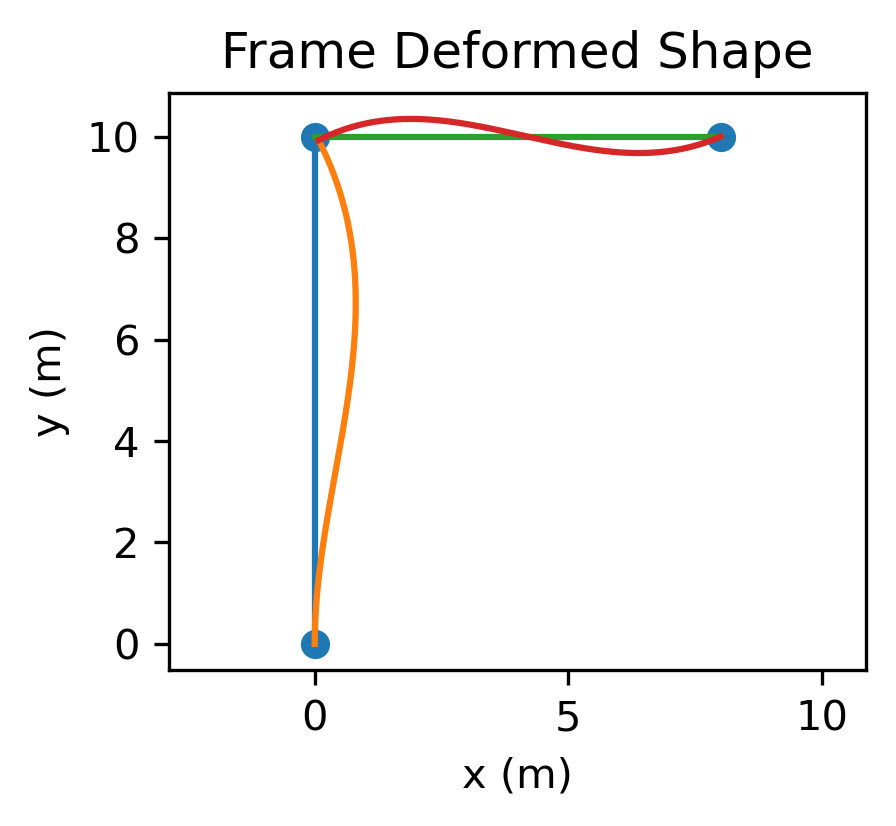

In [264]:
u = u_global.tolist()

plot_deformed_frame_2d(nodes, elements, u, scale=20, npts=500)

### Response for Question 3

For Question 3, the agreement is still very solid. My hand calculation gave about $u_{2x}=3.954\ \text{mm}$, $u_{2y}=-3.600\ \text{mm}$, and $\theta_2=0.02534\ \text{rad}$. The code result was $u_{2x}=3.954\ \text{mm}$, $u_{2y}=-3.599\ \text{mm}$, and $\theta_2\approx 0.025\ \text{rad}$. For reactions, the hand result was about $F_{1x}=-126.962\ \text{kN}$ and $M_1=223.557\ \text{kN}\cdot\text{m}$, while the code gave $F_{1x}=-126.961\ \text{kN}$ and $M_1=223.555\ \text{kN}\cdot\text{m}$. So the trend and magnitudes are all consistent. There are a few small differences in the last decimals, but nothing that changes the interpretation of the result.

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics
- What part felt hardest? Describe in speciics
- One bug you encountered and how you fixed it.
- One thing you still don’t understand.
- If you used collaboration or AI tools, briefly describe how.


### YOUR RESPONSE HERE

- What part felt easiest? Describe in speciics

    All of them are easy.

- What part felt hardest? Describe in speciics

    None.

- One bug you encountered and how you fixed it.
    
    None.

- One thing you still don’t understand.

    None.

- If you used collaboration or AI tools, briefly describe how.

    I didn't use any AI tools， this part was really simple.